# RCN floorspace transactions

Explore the RCiWN (RCN) microdata under `data/raw/floorspace`:

- **`lokale.gpkg`** — flat / premises transactions (points, EPSG:2180)
- **`budynki_bdot10k.gpkg`** — building transactions with BDOT10k floors / usable-area enrichment (polygons, EPSG:2180)

National layers are multi-GB, so this notebook never loads them whole. Attribute summaries use SQLite; choropleths join powiat (`teryt`) counts onto `communes_2021.gpkg` dissolved to powiat; a city close-up loads a filtered geometry subset.

Maps are displayed only (not written to disk). Before committing, clear outputs:

```bash
python scripts/strip_notebook_outputs.py notebooks/03_RCN_data.ipynb
```

In [ ]:
# --- config ---
YEAR_MIN, YEAR_MAX = 2006, 2025
CLOSEUP_POWIAT = "1261"  # Kraków city powiat (TERYT); used for local maps
HOUSE_FOOTPRINT_MAX = 3500  # max building polygons to draw in the close-up
COMMUNES_GPKG = "communes_2021.gpkg"


In [ ]:
from pathlib import Path
import shutil
import sqlite3
import struct
import subprocess
import sys

import ipynbname
import matplotlib

# Prefer inline so figures embed when the notebook is executed headlessly
try:
    import matplotlib_inline  # noqa: F401
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from shapely.geometry import Point

try:
    REPO_ROOT = Path(ipynbname.path()).parent.parent
except Exception:
    # Headless / nbclient execution (no Jupyter connection file)
    here = Path.cwd()
    REPO_ROOT = here.parent if here.name == "notebooks" else here

DATA_ROOT = REPO_ROOT / "data"
FLOORSPACE_DIR = DATA_ROOT / "raw" / "floorspace"
LOKALE_GPKG = FLOORSPACE_DIR / "lokale.gpkg"
BUDYNKI_GPKG = FLOORSPACE_DIR / "budynki_bdot10k.gpkg"
COMMUNES_PATH = DATA_ROOT / "processed" / "shapefiles" / COMMUNES_GPKG

sys.path.insert(0, str(REPO_ROOT / "scripts" / "floorspace"))
from config import CRS_RCN, CRS_COMMUNES  # noqa: E402


def _kpsewhich(name: str) -> str:
    if not shutil.which("kpsewhich"):
        return ""
    return subprocess.run(
        ["kpsewhich", name], capture_output=True, text=True
    ).stdout.strip()


if not _kpsewhich("type1cm.sty"):
    shim_dir = Path.home() / "texmf" / "tex" / "latex" / "type1cm"
    shim_dir.mkdir(parents=True, exist_ok=True)
    (shim_dir / "type1cm.sty").write_text(
        "% Shim for matplotlib usetex: map type1cm -> cm-super type1ec.\n"
        "\\ProvidesPackage{type1cm}\n"
        "\\RequirePackage{type1ec}\n"
    )

_latex_preamble = r"\usepackage[T1]{fontenc}\usepackage{amsmath}\usepackage{amssymb}"
if _kpsewhich("siunitx.sty"):
    _latex_preamble += r"\usepackage{siunitx}[=v2]"

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 16.0,
    "font.family": "serif",
    "font.serif": "Palatino",
    "axes.titlesize": "medium",
    "figure.titlesize": "large",
    "legend.fontsize": "medium",
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.autolayout": True,
    "text.usetex": True,
    "text.latex.preamble": _latex_preamble,
})

_PL_LATEX = {
    "ą": r"\k{a}", "ć": r"\'c", "ę": r"\k{e}", "ł": r"\l{}",
    "ń": r"\'n", "ó": r"\'o", "ś": r"\'s", "ź": r"\'z", "ż": r"\.{z}",
    "Ą": r"\k{A}", "Ć": r"\'C", "Ę": r"\k{E}", "Ł": r"\L{}",
    "Ń": r"\'N", "Ó": r"\'O", "Ś": r"\'S", "Ź": r"\'Z", "Ż": r"\.{Z}",
}


def _fix_utf8_mojibake(s: str) -> str:
    try:
        return s.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def latex_text(s: str) -> str:
    s = _fix_utf8_mojibake(str(s))
    for ch, rep in _PL_LATEX.items():
        s = s.replace(ch, rep)
    return s.replace("_", r"\_").replace("&", r"\&").replace("%", r"\%")


_ENV_SIZE = {0: 0, 1: 32, 2: 48, 3: 48, 4: 64}


def _read_gpkg_point(blob: bytes):
    """Parse a GPKG POINT BLOB -> (x, y) in the layer CRS."""
    flags = blob[3]
    env = (flags >> 1) & 0x07
    off = 8 + _ENV_SIZE.get(env, 0)
    end = "<" if blob[off] == 1 else ">"
    return struct.unpack_from(end + "dd", blob, off + 5)


def sql_df(gpkg: Path, query: str) -> pd.DataFrame:
    with sqlite3.connect(gpkg) as con:
        return pd.read_sql_query(query, con)


YEAR_WHERE = (
    f"dok_data GLOB '20[0-2][0-9]*' "
    f"AND CAST(substr(dok_data, 1, 4) AS INTEGER) BETWEEN {YEAR_MIN} AND {YEAR_MAX}"
)


## 1. Inventory

Row counts and categorical mixes from attribute tables only (no geometries). RCN `teryt` is the **4-digit powiat** code, not gmina.

In [ ]:
n_lokale = sql_df(LOKALE_GPKG, "SELECT COUNT(*) AS n FROM lokale")["n"].iloc[0]
n_budynki = sql_df(BUDYNKI_GPKG, "SELECT COUNT(*) AS n FROM budynki")["n"].iloc[0]

lok_func = sql_df(
    LOKALE_GPKG,
    "SELECT COALESCE(lok_funkcja, '(missing)') AS category, COUNT(*) AS n "
    "FROM lokale GROUP BY 1 ORDER BY n DESC",
)
bud_nier = sql_df(
    BUDYNKI_GPKG,
    "SELECT COALESCE(nier_rodzaj, '(missing)') AS category, COUNT(*) AS n "
    "FROM budynki GROUP BY 1 ORDER BY n DESC",
)
bud_match = sql_df(
    BUDYNKI_GPKG,
    "SELECT COALESCE(match_type, '(missing)') AS category, COUNT(*) AS n "
    "FROM budynki "
    "WHERE nier_rodzaj = 'nieruchomoscGruntowaZabudowana' AND is_residential = 1 "
    "GROUP BY 1 ORDER BY n DESC",
)

n_flats_res = int(
    lok_func.loc[lok_func["category"] == "mieszkalna", "n"].sum()
)
n_houses_res = int(
    sql_df(
        BUDYNKI_GPKG,
        "SELECT COUNT(*) AS n FROM budynki "
        "WHERE nier_rodzaj = 'nieruchomoscGruntowaZabudowana' AND is_residential = 1",
    )["n"].iloc[0]
)

print(
    f"lokale: {n_lokale:,} rows  |  residential flats (lok_funkcja=mieszkalna): {n_flats_res:,}"
)
print(
    f"budynki_bdot10k: {n_budynki:,} rows  |  "
    f"residential built-up plots: {n_houses_res:,}"
)
print(lok_func.head(8).to_string(index=False))
print(bud_nier.to_string(index=False))
print(bud_match.to_string(index=False))


lokale: 2,593,413 rows  |  residential flats (lok_funkcja=mieszkalna): 2,129,379
budynki_bdot10k: 6,233,436 rows  |  residential built-up plots: 815,484
        category       n
      mieszkalna 2129379
           garaz  214298
       (missing)  136489
            inne   87751
handlowoUslugowa   23043
         biurowa    2310
     produkcyjna     143
                         category       n
             nieruchomoscLokalowa 4733575
   nieruchomoscGruntowaZabudowana 1407848
            nieruchomoscBudynkowa   36451
nieruchomoscGruntowaNiezabudowana   31491
                        (missing)   24071
 category      n
  overlap 672223
  nearest 135395
unmatched   7866


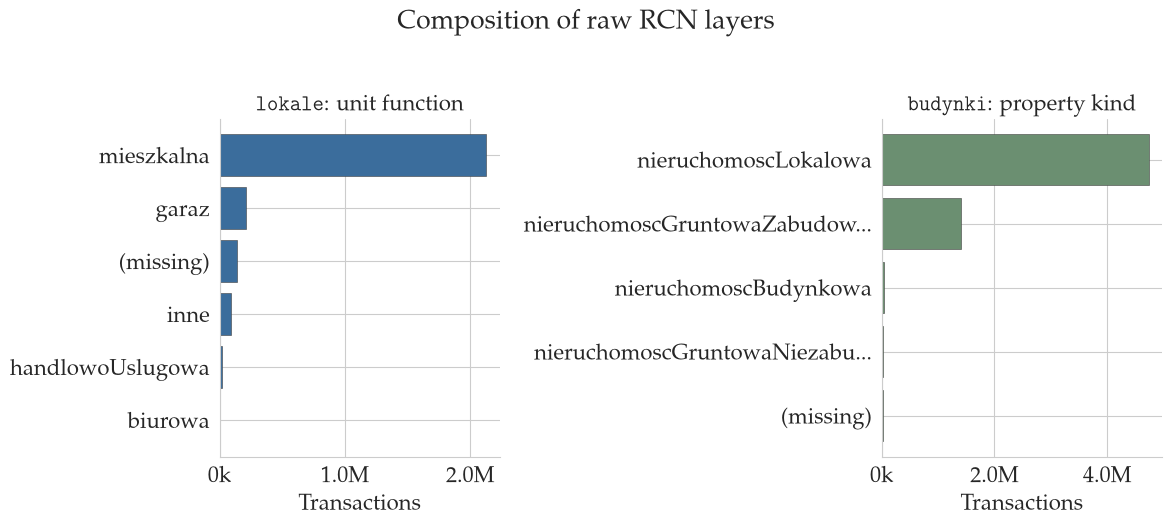

In [ ]:
def _short_label(s: str, maxlen: int = 28) -> str:
    s = str(s)
    return s if len(s) <= maxlen else s[: maxlen - 1] + "..."


fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

for ax, df, title, color in [
    (axes[0], lok_func.head(6), r"\texttt{lokale}: unit function", "#3B6D9C"),
    (axes[1], bud_nier, r"\texttt{budynki}: property kind", "#6B8F71"),
]:
    plot_df = df.iloc[::-1].copy()
    labels = [latex_text(_short_label(c)) for c in plot_df["category"]]
    ax.barh(labels, plot_df["n"].to_numpy(), color=color, edgecolor="0.25", linewidth=0.4)
    ax.set_xlabel(r"Transactions")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))
    sns.despine(ax=ax)

fig.suptitle(r"Composition of raw RCN layers", y=1.02)
plt.show()


## 2. Spatial coverage by powiat

Residential-filter counts aggregated by RCN `teryt`, mapped on commune polygons dissolved to powiat (`JPT_KOD_JE` prefix) from `communes_2021.gpkg` (EPSG:3035).

In [ ]:
flats_by_powiat = sql_df(
    LOKALE_GPKG,
    f"""
    SELECT teryt AS powiat, COUNT(*) AS n_flats
    FROM lokale
    WHERE lok_funkcja = 'mieszkalna' AND {YEAR_WHERE}
    GROUP BY teryt
    """,
)
houses_by_powiat = sql_df(
    BUDYNKI_GPKG,
    f"""
    SELECT teryt AS powiat, COUNT(*) AS n_houses
    FROM budynki
    WHERE nier_rodzaj = 'nieruchomoscGruntowaZabudowana'
      AND is_residential = 1
      AND {YEAR_WHERE}
    GROUP BY teryt
    """,
)

communes = gpd.read_file(COMMUNES_PATH, layer="communes")
communes["powiat"] = communes["JPT_KOD_JE"].astype(str).str[:4]
powiaty = communes.dissolve(by="powiat", as_index=False)[["powiat", "geometry"]]

map_df = (
    powiaty.merge(flats_by_powiat, on="powiat", how="left")
    .merge(houses_by_powiat, on="powiat", how="left")
)
map_df["n_flats"] = map_df["n_flats"].fillna(0).astype(int)
map_df["n_houses"] = map_df["n_houses"].fillna(0).astype(int)

print(
    f"Powiats on map: {len(map_df):,}  |  "
    f"flats {YEAR_MIN}–{YEAR_MAX}: {map_df['n_flats'].sum():,}  |  "
    f"houses: {map_df['n_houses'].sum():,}"
)


Powiats on map: 380  |  flats 2006–2025: 2,019,836  |  houses: 766,793


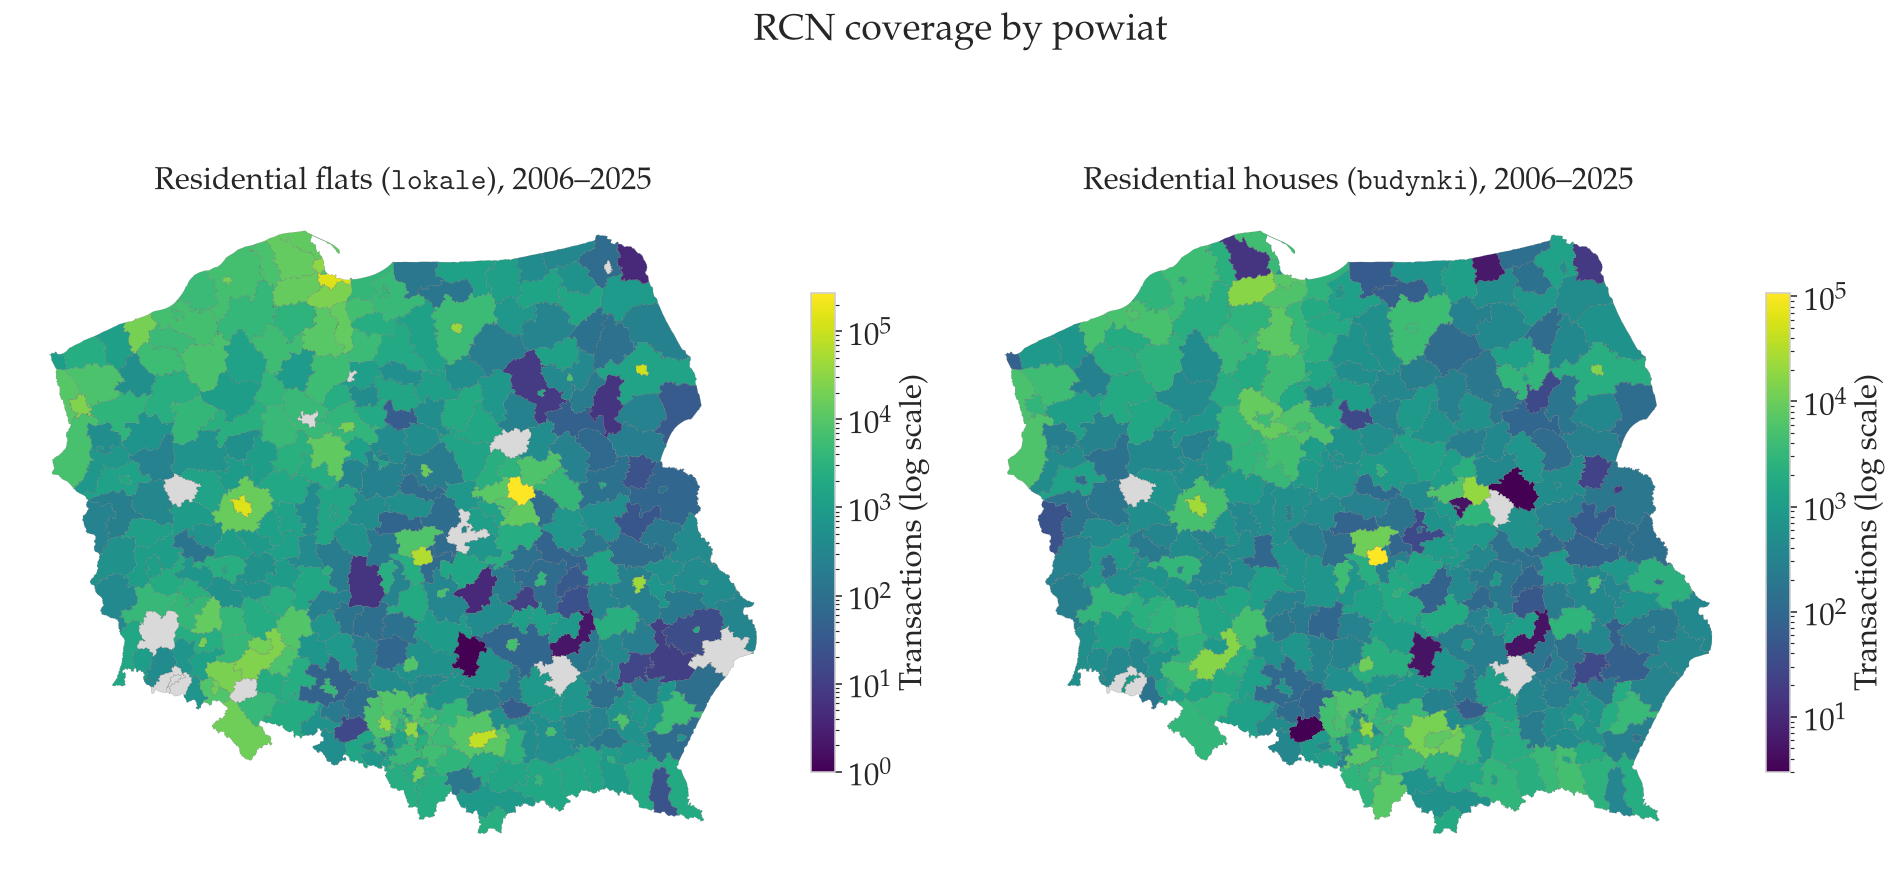

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7.2), dpi=140)

for ax, col, title in [
    (axes[0], "n_flats", r"Residential flats (\texttt{lokale})"),
    (axes[1], "n_houses", r"Residential houses (\texttt{budynki})"),
]:
    plot_gdf = map_df.copy()
    plot_gdf.loc[plot_gdf[col] <= 0, col] = pd.NA
    vals = plot_gdf[col].dropna()
    norm = LogNorm(vmin=max(float(vals.min()), 1), vmax=float(vals.max()))
    plot_gdf.plot(
        column=col,
        ax=ax,
        cmap="viridis",
        norm=norm,
        edgecolor="0.35",
        linewidth=0.08,
        legend=True,
        legend_kwds={
            "label": r"Transactions (log scale)",
            "shrink": 0.55,
            "pad": 0.02,
        },
        missing_kwds={"color": "0.85", "edgecolor": "0.35", "linewidth": 0.08},
    )
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(rf"{title}, {YEAR_MIN}--{YEAR_MAX}")

fig.suptitle(r"RCN coverage by powiat", y=0.98)
plt.show()


## 3. Transactions over time

Annual counts for residential flats and residential built-up houses (same filters as the maps).

In [ ]:
years_flats = sql_df(
    LOKALE_GPKG,
    f"""
    SELECT CAST(substr(dok_data, 1, 4) AS INTEGER) AS year, COUNT(*) AS n
    FROM lokale
    WHERE lok_funkcja = 'mieszkalna' AND {YEAR_WHERE}
    GROUP BY year ORDER BY year
    """,
)
years_houses = sql_df(
    BUDYNKI_GPKG,
    f"""
    SELECT CAST(substr(dok_data, 1, 4) AS INTEGER) AS year, COUNT(*) AS n
    FROM budynki
    WHERE nier_rodzaj = 'nieruchomoscGruntowaZabudowana'
      AND is_residential = 1
      AND {YEAR_WHERE}
    GROUP BY year ORDER BY year
    """,
)

market_years = sql_df(
    LOKALE_GPKG,
    f"""
    SELECT CAST(substr(dok_data, 1, 4) AS INTEGER) AS year,
           COALESCE(tran_rodzaj_rynku, '(missing)') AS market,
           COUNT(*) AS n
    FROM lokale
    WHERE lok_funkcja = 'mieszkalna' AND {YEAR_WHERE}
    GROUP BY year, market
    ORDER BY year, market
    """,
)


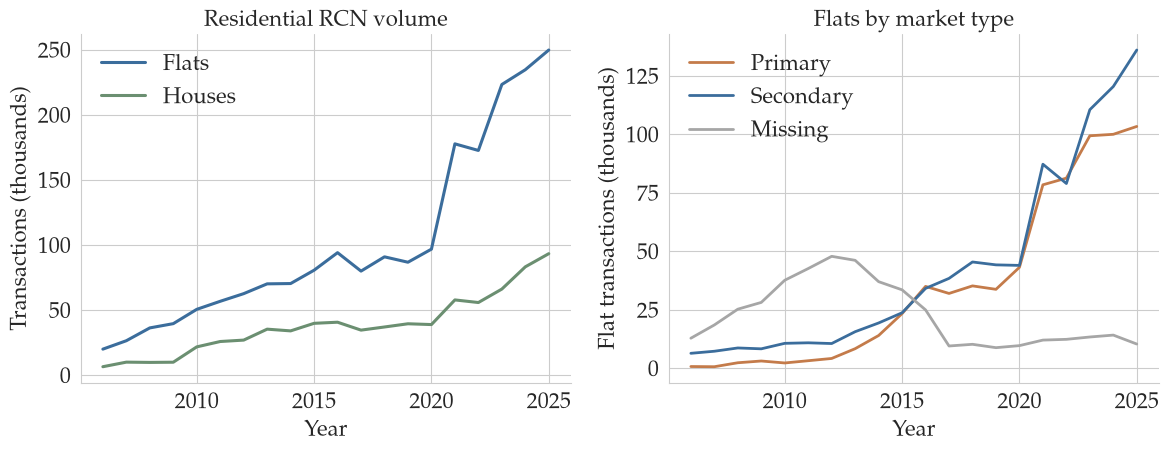

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.plot(years_flats["year"], years_flats["n"] / 1e3, color="#3B6D9C", lw=2.2, label=r"Flats")
ax.plot(years_houses["year"], years_houses["n"] / 1e3, color="#6B8F71", lw=2.2, label=r"Houses")
ax.set_xlabel(r"Year")
ax.set_ylabel(r"Transactions (thousands)")
ax.set_title(r"Residential RCN volume")
ax.legend(frameon=False)
sns.despine(ax=ax)

ax = axes[1]
market_map = {
    "pierwotny": r"Primary",
    "wtorny": r"Secondary",
    "(missing)": r"Missing",
}
colors = {"pierwotny": "#C47B4A", "wtorny": "#3B6D9C", "(missing)": "0.65"}
for key, label in market_map.items():
    sub = market_years[market_years["market"] == key]
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["n"] / 1e3, color=colors[key], lw=2.0, label=label)
ax.set_xlabel(r"Year")
ax.set_ylabel(r"Flat transactions (thousands)")
ax.set_title(r"Flats by market type")
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.show()


## 4. City close-up

Kraków powiat (`CLOSEUP_POWIAT`): flat transaction locations as a hexbin density (points parsed from the GPKG without materialising full GeoPandas rows for the whole layer), plus a sample of residential house footprints from `budynki_bdot10k`.

In [ ]:
powiat_name_row = communes.loc[
    communes["powiat"] == CLOSEUP_POWIAT, "JPT_NAZWA_"
]
# Prefer the urban gmina name when several gminas share the powiat prefix
closeup_label = (
    powiat_name_row.iloc[0] if len(powiat_name_row) else CLOSEUP_POWIAT
)
if CLOSEUP_POWIAT == "1261":
    closeup_label = "Kraków"
elif CLOSEUP_POWIAT == "1465":
    closeup_label = "Warszawa"
elif CLOSEUP_POWIAT == "2261":
    closeup_label = "Gdańsk"

with sqlite3.connect(LOKALE_GPKG) as con:
    flat_rows = con.execute(
        f"""
        SELECT geom, lok_pow_uzyt, lok_cena_brutto, dok_data
        FROM lokale
        WHERE teryt = ? AND lok_funkcja = 'mieszkalna' AND {YEAR_WHERE}
        """,
        (CLOSEUP_POWIAT,),
    ).fetchall()

xs, ys, areas, prices = [], [], [], []
for geom, area, price, _dok in flat_rows:
    if geom is None:
        continue
    try:
        x, y = _read_gpkg_point(geom)
    except Exception:
        continue
    xs.append(x)
    ys.append(y)
    areas.append(pd.to_numeric(area, errors="coerce"))
    prices.append(pd.to_numeric(price, errors="coerce"))

flats_pts = gpd.GeoDataFrame(
    {
        "area": np.asarray(areas, dtype=float),
        "price": np.asarray(prices, dtype=float),
    },
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=CRS_RCN,
)
flats_pts["ppm2"] = flats_pts["price"] / flats_pts["area"]

houses_poly = gpd.read_file(
    BUDYNKI_GPKG,
    where=(
        f"teryt = '{CLOSEUP_POWIAT}' "
        "AND nier_rodzaj = 'nieruchomoscGruntowaZabudowana' "
        "AND is_residential = 1 AND match_type = 'overlap'"
    ),
    max_features=HOUSE_FOOTPRINT_MAX,
    columns=["usable_area_est_m2", "footprint_m2", "dok_data", "bud_rodzaj"],
)

boundary = (
    communes.loc[communes["powiat"] == CLOSEUP_POWIAT]
    .to_crs(CRS_RCN)
    .dissolve()
)

print(
    f"{closeup_label} ({CLOSEUP_POWIAT}): "
    f"{len(flats_pts):,} flat points, {len(houses_poly):,} house footprints"
)


Kraków (1261): 81,364 flat points, 3,500 house footprints


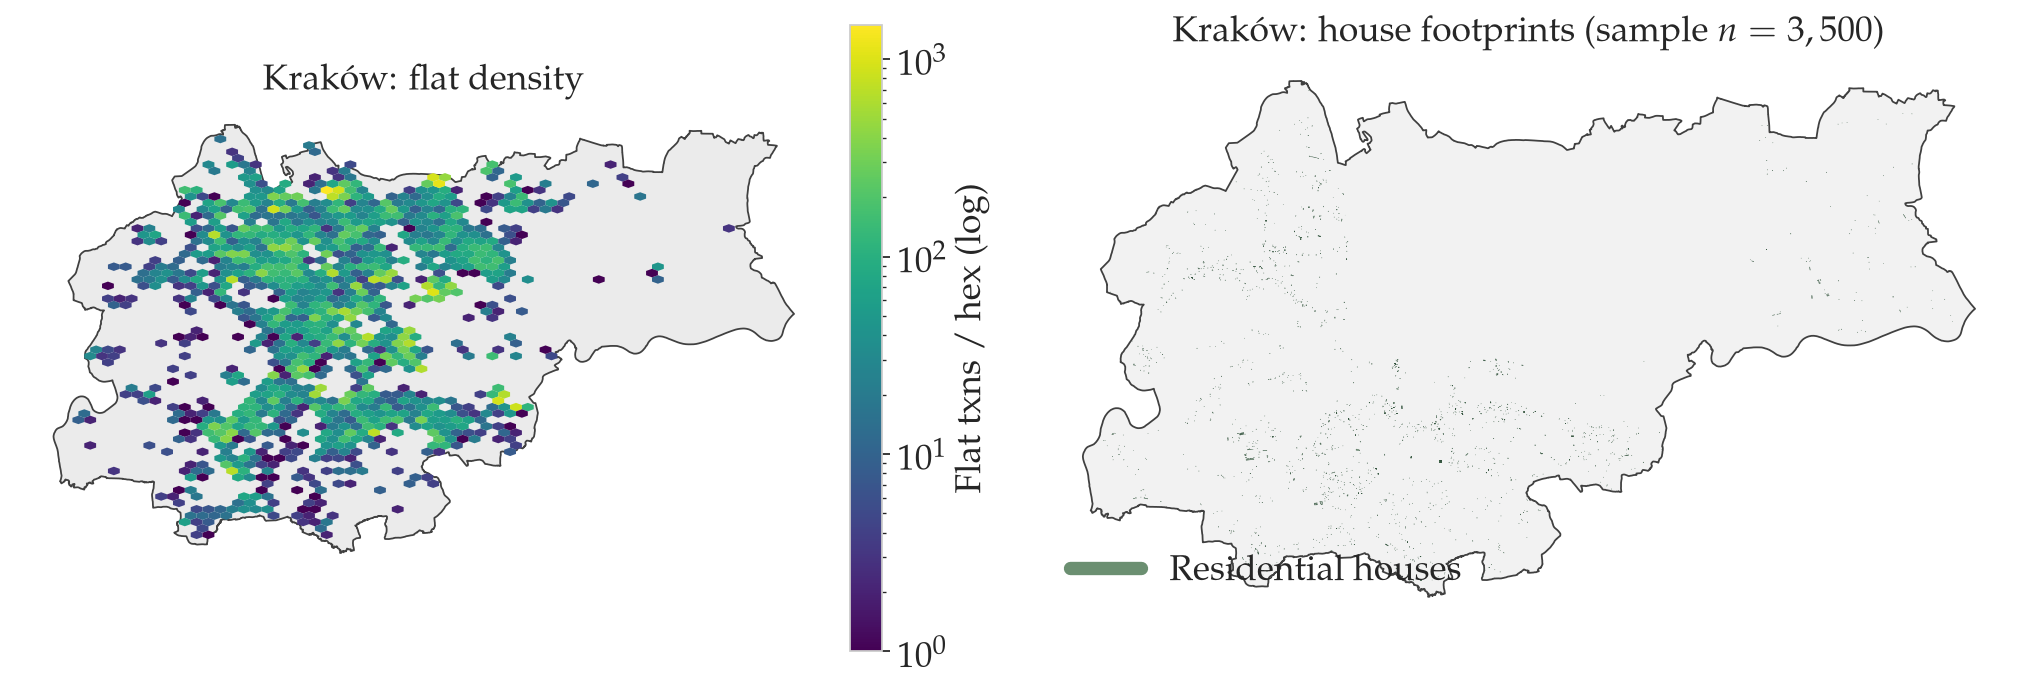

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), dpi=160)

ax = axes[0]
boundary.plot(ax=ax, facecolor="0.92", edgecolor="0.25", linewidth=0.8)
hb = ax.hexbin(
    flats_pts.geometry.x,
    flats_pts.geometry.y,
    gridsize=55,
    mincnt=1,
    cmap="viridis",
    linewidths=0.0,
    bins="log",
)
cb = fig.colorbar(hb, ax=ax, shrink=0.65, pad=0.02)
cb.set_label(r"Flat txns / hex (log)")
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(rf"{latex_text(closeup_label)}: flat density")

ax = axes[1]
boundary.plot(ax=ax, facecolor="0.95", edgecolor="0.25", linewidth=0.8)
houses_poly.plot(
    ax=ax,
    facecolor="#6B8F71",
    edgecolor="#2F4F3A",
    linewidth=0.15,
    alpha=0.85,
)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(
    rf"{latex_text(closeup_label)}: house footprints"
    + (rf" (sample $n={len(houses_poly):,}$)" if len(houses_poly) >= HOUSE_FOOTPRINT_MAX else "")
)
ax.legend(
    handles=[Line2D([0], [0], color="#6B8F71", lw=6, label=r"Residential houses")],
    frameon=False,
    loc="lower left",
)

plt.show()


## 5. Local price and size distributions

Usable area and unit price for residential flats in the close-up powiat (raw RCN fields; light domain trim only).

Trimmed sample: 46,166 / 81,364 flat points


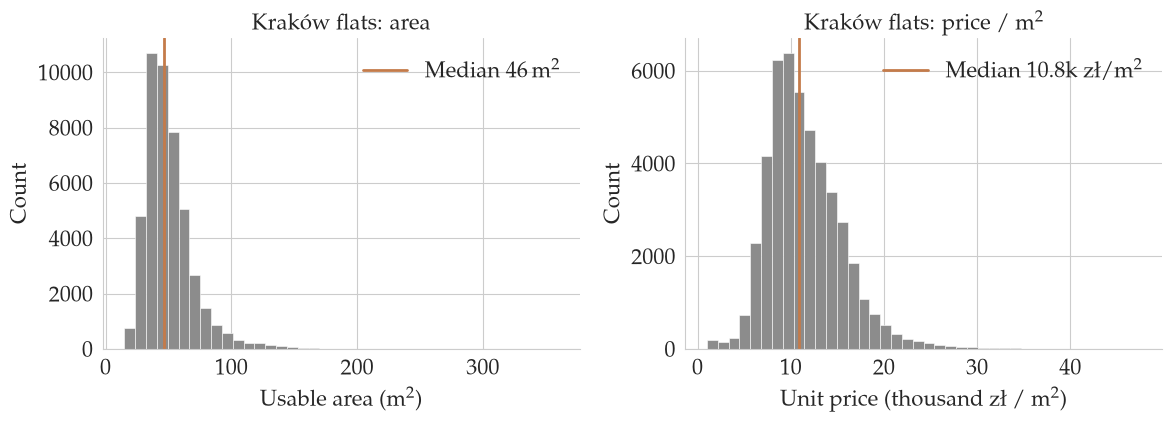

In [ ]:
sample = flats_pts.dropna(subset=["area", "ppm2"]).copy()
sample = sample[(sample["area"] >= 15) & (sample["area"] <= 400)]
sample = sample[(sample["ppm2"] >= 1_000) & (sample["ppm2"] <= 50_000)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(sample["area"], bins=40, color="0.55", edgecolor="white", linewidth=0.4)
ax.axvline(sample["area"].median(), color="#C47B4A", lw=2.0, label=rf"Median ${sample['area'].median():.0f}\,\mathrm{{m}}^2$")
ax.set_xlabel(r"Usable area ($\mathrm{m}^2$)")
ax.set_ylabel(r"Count")
ax.set_title(rf"{latex_text(closeup_label)} flats: area")
ax.legend(frameon=False)
sns.despine(ax=ax)

ax = axes[1]
ax.hist(sample["ppm2"] / 1e3, bins=40, color="0.55", edgecolor="white", linewidth=0.4)
ax.axvline(
    sample["ppm2"].median() / 1e3,
    color="#C47B4A",
    lw=2.0,
    label=rf"Median ${sample['ppm2'].median()/1e3:.1f}$k zł/m$^2$",
)
ax.set_xlabel(r"Unit price (thousand zł / $\mathrm{m}^2$)")
ax.set_ylabel(r"Count")
ax.set_title(rf"{latex_text(closeup_label)} flats: price / m$^2$")
ax.legend(frameon=False)
sns.despine(ax=ax)

print(f"Trimmed sample: {len(sample):,} / {len(flats_pts):,} flat points")
plt.show()
